In [2]:
%%writefile /home/afzal/projects/knee-oa-classification/src/models.py
"""CNN architectures for knee OA KL-grade classification (all trained from scratch)."""
import keras
from keras import layers


def conv_block(x, filters, name):
    """Two 3x3 conv -> BatchNorm -> ReLU layers, then 2x2 max pooling."""
    for i in (1, 2):
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv{i}")(x)
        x = layers.BatchNormalization(name=f"{name}_bn{i}")(x)
        x = layers.ReLU(name=f"{name}_relu{i}")(x)
    return layers.MaxPooling2D(2, name=f"{name}_pool")(x)


def build_baseline_cnn(input_shape=(224, 224, 1), num_classes=5,
                       filters=(32, 64, 128, 256), dropout=0.3):
    inputs = keras.Input(shape=input_shape, name="xray")
    x = inputs
    for i, f in enumerate(filters, start=1):
        x = conv_block(x, f, name=f"block{i}")
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(dropout, name="dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="kl_grade")(x)
    return keras.Model(inputs, outputs, name="baseline_cnn")

Overwriting /home/afzal/projects/knee-oa-classification/src/models.py


In [3]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PROJECT = Path.home() / "projects/knee-oa-classification"
MODELS = PROJECT / "models"
REPORTS = PROJECT / "reports"
sys.path.insert(0, str(PROJECT / "src"))

import keras
import data
import evaluation as ev
import models

X_train, y_train = data.load_split("train")
X_val, y_val = data.load_split("val")
train_ds = data.make_dataset(X_train, y_train, batch_size=32, shuffle=True)
val_ds = data.make_dataset(X_val, y_val, batch_size=64)
print("train", X_train.shape, "| val", X_val.shape)

I0000 00:00:1791027454.345203    4910 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791027454.383940    4910 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791027455.809165    4910 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791027457.905148    4910 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB mem

train (5778, 224, 224) | val (826, 224, 224)


In [4]:
ev.set_seed(42)
model = models.build_baseline_cnn()
model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xray (InputLayer)               │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (ReLU)             │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (ReLU)             │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (ReLU)             │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (ReLU)             │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (ReLU)             │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (ReLU)             │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_bn1 (BatchNormalization) │ (None, 28, 28, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_relu1 (ReLU)             │ (None, 28, 28, 256)    │             

 Total params: 1,175,845 (4.49 MB)

 Trainable params: 1,173,925 (4.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [5]:
RUN = "baseline_cnn_v1"
CONFIG = {"model": "baseline_cnn", "filters": [32, 64, 128, 256], "dropout": 0.3,
          "optimizer": "adam", "lr": 1e-3, "batch_size": 32, "max_epochs": 60,
          "class_weights": None, "augmentation": None, "seed": 42}

model.compile(optimizer=keras.optimizers.Adam(CONFIG["lr"]),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

ckpt = MODELS / f"{RUN}.keras"
callbacks = [
    ev.BalancedAccuracyCallback(val_ds, y_val),
    keras.callbacks.ModelCheckpoint(ckpt, monitor="val_balanced_accuracy", mode="max",
                                    save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_balanced_accuracy", mode="max", patience=12,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4,
                                      min_lr=1e-5, verbose=1),
    keras.callbacks.CSVLogger(REPORTS / f"{RUN}_history.csv"),
]

history = model.fit(train_ds, validation_data=val_ds,
                    epochs=CONFIG["max_epochs"], callbacks=callbacks)

Epoch 1/60


/home/afzal/miniconda3/envs/knee-oa/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1791027526.413946    5104 service.cc:153] XLA service 0x763948040b00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791027526.414001    5104 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.27.0)
I0000 00:00:1791027526.467182    5104 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1791027526.774390    5104 cuda_dnn.cc:461] Loaded cuDNN version 92700
I0000 00:00:1791027526.832510    5104 dot_merge

180/181 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.3964 - loss: 1.3912

I0000 00:00:1791027561.443502    5103 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5635__.94


181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.3963 - loss: 1.3910  val_balanced_accuracy: 0.2000 | val_qwk: 0.0000
181/181 ━━━━━━━━━━━━━━━━━━━━ 63s 249ms/step - accuracy: 0.3963 - loss: 1.3910 - val_accuracy: 0.2567 - val_loss: 1.6429 - val_balanced_accuracy: 0.2000 - val_qwk: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/60
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.4737 - loss: 1.1983  val_balanced_accuracy: 0.2000 | val_qwk: 0.0000
181/181 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - accuracy: 0.4737 - loss: 1.1983 - val_accuracy: 0.2567 - val_loss: 1.6211 - val_balanced_accuracy: 0.2000 - val_qwk: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/60
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.5062 - loss: 1.1370  val_balanced_accuracy: 0.2132 | val_qwk: 0.0101
181/181 ━━━━━━━━━━━━━━━━━━━━ 21s 114ms/step - accuracy: 0.5062 - loss: 1.1370 - val_accuracy: 0.0448 - val_loss: 5.6697 - val_balanced_accuracy: 0.2132 - val_qwk: 0.0101 - learning_rate: 0.0010
Epoch 4/60

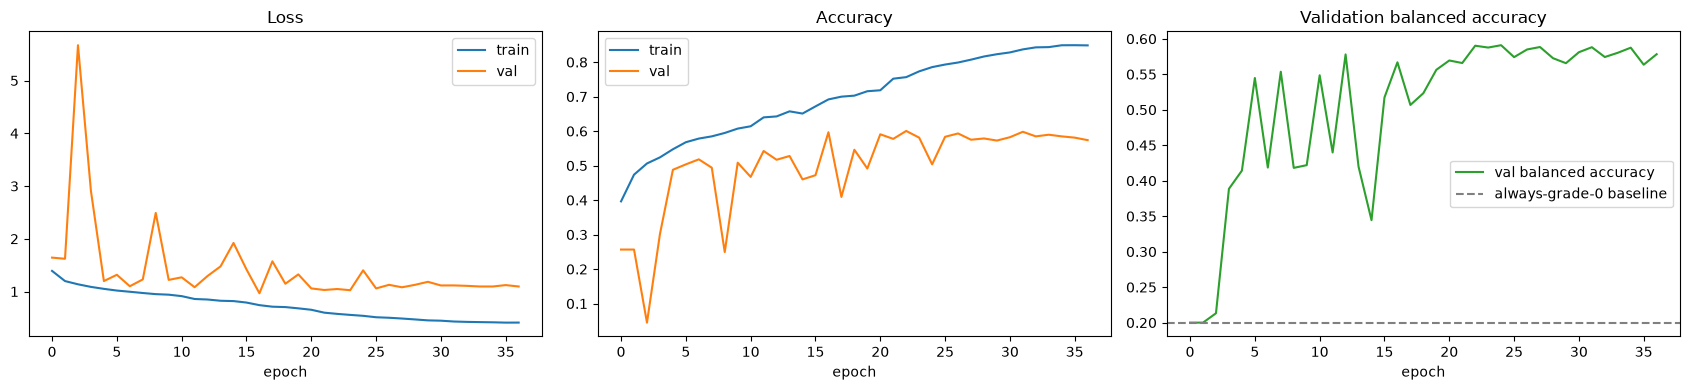

In [6]:
h = history.history
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].plot(h["loss"], label="train"); axes[0].plot(h["val_loss"], label="val")
axes[0].set_title("Loss")
axes[1].plot(h["accuracy"], label="train"); axes[1].plot(h["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[2].plot(h["val_balanced_accuracy"], color="C2", label="val balanced accuracy")
axes[2].axhline(0.2, ls="--", color="gray", label="always-grade-0 baseline")
axes[2].set_title("Validation balanced accuracy")
for ax in axes:
    ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / f"{RUN}_curves.png", dpi=150)
plt.show()

Balanced accuracy: 0.5910 | Accuracy: 0.5036 | QWK: 0.5563 | Macro F1: 0.5273

              precision    recall  f1-score   support

           0      0.741     0.375     0.498       328
           1      0.222     0.078     0.116       153
           2      0.399     0.840     0.541       212
           3      0.624     0.736     0.675       106
           4      0.714     0.926     0.806        27

    accuracy                          0.504       826
   macro avg      0.540     0.591     0.527       826
weighted avg      0.541     0.504     0.471       826



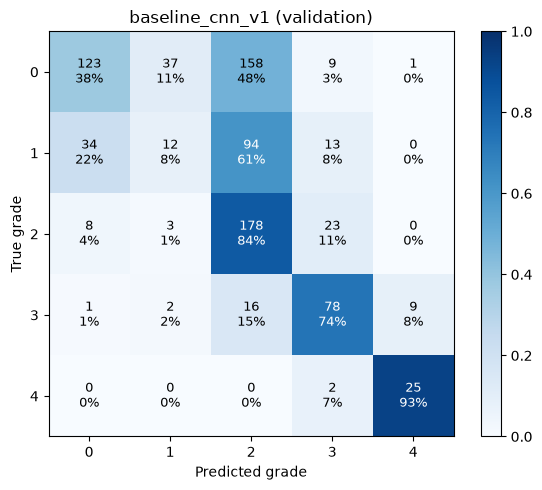

{'timestamp': '2026-10-03T11:55:57',
 'run': 'baseline_cnn_v1',
 'split': 'val',
 'balanced_accuracy': 0.591,
 'accuracy': 0.5036,
 'qwk': 0.5563,
 'macro_f1': 0.5273,
 'recall_g0': 0.375,
 'recall_g1': 0.0784,
 'recall_g2': 0.8396,
 'recall_g3': 0.7358,
 'recall_g4': 0.9259,
 'config': '{"model": "baseline_cnn", "filters": [32, 64, 128, 256], "dropout": 0.3, "optimizer": "adam", "lr": 0.001, "batch_size": 32, "max_epochs": 60, "class_weights": null, "augmentation": null, "seed": 42, "best_epoch": 25, "epochs_run": 37}'}

In [7]:
best = keras.models.load_model(ckpt)
y_pred = best.predict(val_ds, verbose=0).argmax(axis=1)

m = ev.evaluate_predictions(y_val, y_pred, title=f"{RUN} (validation)",
                            save_path=REPORTS / f"cm_{RUN}.png")

best_epoch = int(np.argmax(h["val_balanced_accuracy"])) + 1
ev.log_run(RUN, {**CONFIG, "best_epoch": best_epoch, "epochs_run": len(h["loss"])}, m)